In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
from sklearn.metrics import mean_squared_error as mse

In [104]:
#importing dataset

df = pd.read_excel("Данные по регионам\\region 0.xlsx")
features = df["temperature 0"]
df.head(7)

,Date,consumption 0,temperature 0,day type
0,2010-01-01,30.972282,7.0,3
1,2010-01-02,29.846362,10.0,3
2,2010-01-03,36.359652,6.0,3
3,2010-01-04,41.859071,-1.0,3
4,2010-01-05,43.567304,-6.0,3
5,2010-01-06,41.690585,-2.0,1
6,2010-01-07,39.604016,0.0,3


<Axes: >

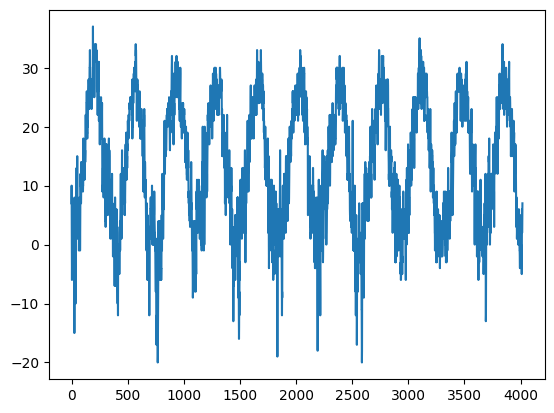

In [18]:
features.plot()

In [105]:
from sklearn.preprocessing import StandardScaler

features = StandardScaler().fit_transform(np.array(features).reshape(-1, 1))
df["temperature 0"] = features
df

,Date,consumption 0,temperature 0,day type
0,2010-01-01,30.972282,-0.605549,3
1,2010-01-02,29.846362,-0.323642,3
2,2010-01-03,36.359652,-0.699518,3
3,2010-01-04,41.859071,-1.357302,3
4,2010-01-05,43.567304,-1.827148,3
...,...,...,...,...
4013,2020-12-27,39.037059,-0.699518,1
4014,2020-12-28,39.631884,-1.075395,0
4015,2020-12-29,38.135933,-0.887457,0
4016,2020-12-30,36.871494,-0.605549,0


In [106]:
def df_to_X_y(df, n_future, n_past):

    df = np.array(df)
    trainX, trainY= [], []

    for i in range(n_past, len(df) - n_future + 1):
        trainX.append(df[i - n_past:i, 2:])
        trainY.append(df[i + n_future - 1:i + n_future, 1])

    return np.array(trainX), np.array(trainY)

n_future = 7
n_past = 120

trainX, trainY = df_to_X_y(df, n_future, n_past)

In [83]:
exps = np.array(df)[:, 2:]

In [84]:
temp = "-1 -2 0 1 -1 -3"
days = "0 0 0 0 0 0"

temp = list(map(float, temp.split()))
days = list(map(int, days.split()))

some_data = np.array([list(i) for i in zip(temp, days)])

In [85]:
features = StandardScaler().fit_transform(some_data[:, 0].reshape(-1, 1))

In [86]:
some_data[:, 0] = features.reshape(6)

In [87]:
some_data

array([[ 0.        ,  0.        ],
       [-0.77459667,  0.        ],
       [ 0.77459667,  0.        ],
       [ 1.54919334,  0.        ],
       [ 0.        ,  0.        ],
       [-1.54919334,  0.        ]])

In [88]:
len(exps)

4018

In [89]:
data = np.append(exps, some_data, axis=0)
data[-6:]

array([[0.0, 0.0],
       [-0.7745966692414834, 0.0],
       [0.7745966692414834, 0.0],
       [1.5491933384829668, 0.0],
       [0.0, 0.0],
       [-1.5491933384829668, 0.0]], dtype=object)

In [90]:
def df_to_X_y_2(df, n_future, n_past):

    trainX = []
    for i in range(n_past, len(df) - n_future + 1):
        trainX.append(df[i - n_past:i])

    return np.array(trainX)

n_future = 7
n_past = 120

train = df_to_X_y_2(data, 7, 120)

In [70]:
len(train)

3898

In [95]:
model.predict(np.asarray(train[:7]).astype("float32"))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step


array([[10.573564],
       [10.317224],
       [10.390437],
       [10.736394],
       [10.87118 ],
       [10.532624],
       [10.015824]], dtype=float32)

In [108]:
testX = trainX[730:-365]
testY = trainY[730:-365]
trainX = trainX[:730]
trainY = trainY[:730]


In [110]:
from keras.models import Sequential
from keras.layers import LSTM
from keras.layers import Dense, Dropout
from keras.optimizers import Adam

In [111]:
model = Sequential()
model.add(LSTM(128, input_shape=(trainX.shape[1], trainX.shape[2])))
model.add(Dropout(0.2))
model.add(Dense(trainY.shape[1]))
model.compile(
    loss=tf.losses.MeanSquaredError(),
    optimizer=Adam(),
    metrics=[tf.metrics.MeanAbsoluteError()]
)
model.summary()

c:\Users\egorl\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_5 (LSTM)                   │ (None, 128)            │        67,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 67,201 (262.50 KB)

 Trainable params: 67,201 (262.50 KB)

 Non-trainable params: 0 (0.00 B)

In [112]:
history = model.fit(np.asarray(trainX).astype('float32'), np.asarray(trainY).astype('float32'), epochs=20)

Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 88ms/step - loss: 690.1199 - mean_absolute_error: 21.2923
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step - loss: 383.6429 - mean_absolute_error: 14.9081
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - loss: 287.7196 - mean_absolute_error: 14.2013
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - loss: 299.6638 - mean_absolute_error: 14.8626
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 89ms/step - loss: 257.6839 - mean_absolute_error: 14.1955
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 92ms/step - loss: 250.6588 - mean_absolute_error: 14.1473
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - loss: 217.8640 - mean_absolute_error: 13.0981
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 98ms/step - loss: 185.6342 - mean_absolute_error: 11.9229
Epoch 9/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 104ms/step - loss: 140.7493 - mean_absolute_error: 9.8908
Epoch 10/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 106ms/step - loss: 109.4804 - mean_absolute_error: 7.6694
Epoch 11/

In [31]:
mse(model.predict(np.asarray(testX[14:21]).astype("float32")).flatten(), testY[14:21])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step


1.0082973083481634

In [97]:
model.predict(np.asarray(train[:7]).astype("float32")).flatten()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step


array([10.573564, 10.317224, 10.390437, 10.736394, 10.87118 , 10.532624,
       10.015824], dtype=float32)

In [33]:
testY[14:21]

array([[7.363721289297094],
       [7.462436090516251],
       [7.362322780252669],
       [7.660871532968405],
       [8.10299401208291],
       [8.197421592765949],
       [8.71601454681884]], dtype=object)

In [9]:
model.save("lstm_0.h5")

In [17]:
model.predict(np.asarray(testX[:7]).astype("float32")).flatten()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


array([8.712504 , 8.649388 , 8.820594 , 8.549687 , 8.355545 , 8.118959 ,
       7.9683814], dtype=float32)

In [210]:
testY[7:14]

array([[8.350622565342448],
       [8.1506694013276],
       [7.809117192536052],
       [7.606997202192225],
       [8.083707772425937],
       [7.658190558541358],
       [7.394244787448791]], dtype=object)

In [98]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
from sklearn.metrics import mean_squared_error as mse


df = pd.read_excel("Данные по регионам\\region 0.xlsx")
features = df["temperature 0"]
df.head(7)


from sklearn.preprocessing import StandardScaler

features = StandardScaler().fit_transform(np.array(features).reshape(-1, 1))
df["temperature 0"] = features

def df_to_X_y(df, n_future, n_past):

    df = np.array(df)
    trainX, trainY= [], []

    for i in range(n_past, len(df) - n_future + 1):
        trainX.append(df[i - n_past:i, 2:])
        trainY.append(df[i + n_future - 1:i + n_future, 1])

    return np.array(trainX), np.array(trainY)

n_future = 7
n_lag = 120

trainX, trainY = df_to_X_y(df, n_future, n_lag)


testX = trainX[730:]
testY = trainY[730:]
trainX = trainX[:730]
trainY = trainY[:730]


from keras.models import Sequential
from keras.layers import LSTM
from keras.layers import Dense, Dropout
from keras.optimizers import Adam


model = Sequential()
model.add(LSTM(128, input_shape=(trainX.shape[1], trainX.shape[2])))
model.add(Dropout(0.2))
model.add(Dense(trainY.shape[1]))
model.compile(
    loss=tf.losses.MeanSquaredError(),
    optimizer=Adam(),
    metrics=[tf.metrics.MeanAbsoluteError()]
)
model.summary()

c:\Users\egorl\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 128)            │        67,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 67,201 (262.50 KB)

 Trainable params: 67,201 (262.50 KB)

 Non-trainable params: 0 (0.00 B)

In [99]:
history = model.fit(np.asarray(trainX).astype('float32'), np.asarray(trainY).astype('float32'), epochs=20)

Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 88ms/step - loss: 673.2592 - mean_absolute_error: 21.0606
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step - loss: 399.7802 - mean_absolute_error: 15.3847
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 94ms/step - loss: 283.2021 - mean_absolute_error: 14.1226
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 100ms/step - loss: 270.4129 - mean_absolute_error: 14.4128
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 105ms/step - loss: 239.3276 - mean_absolute_error: 13.9605
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 103ms/step - loss: 233.9654 - mean_absolute_error: 13.9058
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 90ms/step - loss: 241.1640 - mean_absolute_error: 14.1848
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - loss: 224.0857 - mean_absolute_error: 13.4815
Epoch 9/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 86ms/step - loss: 168.8172 - mean_absolute_error: 11.1726
Epoch 10/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 86ms/step - loss: 142.6463 - mean_absolute_error: 9.2152
Epoch 1

In [113]:
rmses = []
predictions = []


for i in range(len(testX)//7-1):
    if len(testX[i*7:(i+1)*7]) == 7:
        predict = model.predict(np.asarray(testX[i*7:(i+1)*7]).astype("float32")).flatten()
        print(predict)
        predictions.extend(list(predict))
        rmses.append(np.sqrt(mse(predict, testY[i*7:(i+1)*7])))
        model.fit(np.asarray(trainX[i*7:(i+1)*7]).astype('float32'), np.asarray(trainY[i*7:(i+1)*7]).astype('float32'), epochs=20)

    

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 397ms/step
[11.503291 11.368011 11.617083 11.085031 10.718633 10.386714 10.106648]
Epoch 1/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - loss: 11.8230 - mean_absolute_error: 3.1129
Epoch 2/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - loss: 1.6930 - mean_absolute_error: 1.1355
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - loss: 3.9368 - mean_absolute_error: 1.7883
Epoch 4/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - loss: 0.8611 - mean_absolute_error: 0.7305
Epoch 5/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - loss: 1.7353 - mean_absolute_error: 1.1998
Epoch 6/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - loss: 1.9092 - mean_absolute_error: 1.0131
Epoch 7/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - loss: 2.5080 - mean_absolute_error: 1.3827
Epoch 8/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - loss: 4.2924 - mean_absolute_error: 1.6795
Epoch 9/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - loss: 2.9155 - mean_absolute_error: 1.6495
Epoch 10/20
1/1 ━━━━━━━━━━━━━━━━━

c:\Users\egorl\AppData\Local\Programs\Python\Python311\Lib\contextlib.py:155: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


TypeError: 'NoneType' object is not iterable

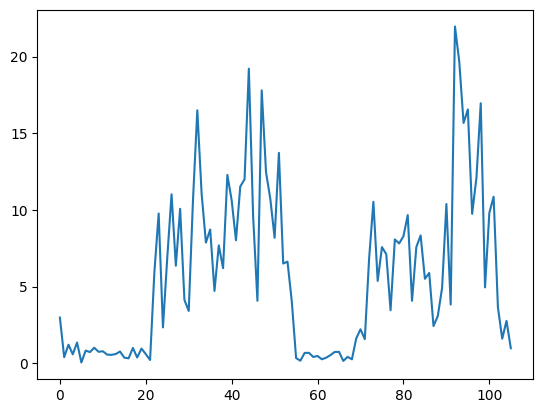

In [114]:
plt.plot(rmses)

In [117]:
model.predict(np.asarray(train[:-7], "float32"))

122/122 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step


array([[7.3155866],
       [7.2433443],
       [7.311615 ],
       ...,
       [7.811103 ],
       [7.8103323],
       [7.840989 ]], dtype=float32)

In [13]:
max(predictions)

55.562702

In [37]:
def confidence_interval(predictions):

    mean = np.mean(predictions)
    std = np.std(predictions)

    lower_bound = mean - 1,96 * (std / np.sqrt(len(predictions)))
    upper_bound = mean + 1,96 * (std / np.sqrt(len(predictions)))

    return lower_bound, upper_bound

# Пример использования функции
bound = confidence_interval(predictions)[0]
print(f"Доверительный интервал с вероятностью 95%: {bound}")

Доверительный интервал с вероятностью 95%: (21.90726089477539, 54.7899635544218)


In [33]:
lower_bound

(21.90726089477539, 54.7899635544218)

In [35]:
for i in range(len(testX)//7):
    print(trainX[i])

[[-0.6055491267532912 3]
 [-0.3236416564864505 3]
 [-0.6995182835089048 3]
 [-1.3573023807981996 3]
 [-1.8271481645762675 3]
 [-1.4512715375538132 1]
 [-1.263333224042586 3]
 [-0.6995182835089048 1]
 [-0.5115799699976776 1]
 [-0.6055491267532912 1]
 [-0.8874565970201319 0]
 [-0.6055491267532912 0]
 [-0.6995182835089048 0]
 [-0.7934874402645183 0]
 [-0.8874565970201319 0]
 [-0.8874565970201319 1]
 [-1.263333224042586 1]
 [-1.263333224042586 0]
 [-1.263333224042586 0]
 [-1.263333224042586 0]
 [-1.1693640672869725 0]
 [-1.075394910531359 0]
 [-1.4512715375538132 1]
 [-1.921117321331881 1]
 [-2.578901418621176 0]
 [-2.6728705753767894 0]
 [-2.6728705753767894 0]
 [-2.296993948354335 0]
 [-1.5452406943094268 0]
 [-0.9814257537757455 1]
 [-0.6055491267532912 1]
 [-0.5115799699976776 0]
 [-0.5115799699976776 0]
 [-1.1693640672869725 0]
 [-1.1693640672869725 0]
 [-1.6392098510650404 0]
 [-2.2030247915987218 1]
 [-1.733179007820654 1]
 [-1.3573023807981996 0]
 [-1.075394910531359 0]
 [-0.793487

In [42]:
len(trainY)

730

In [8]:
a = [1, 2, 3, 2, 1]